- Figure 4a
- Extended Figure 13a
- Extended Figure 13b
- Extended Figure 13c
- Extended Figure 14c

In [20]:
import os
import warnings
warnings.simplefilter('ignore')

import scanpy as sc
import pandas as pd
import numpy as np

import mplscience
import seaborn as sns
import matplotlib.pyplot as plt
import glasbey

In [21]:
adata = sc.read_h5ad('../output/annotated_redo_2025.h5ad')
adata

AnnData object with n_obs × n_vars = 53408 × 29009
    obs: 'sample_id', 'sample_info', 'age', 'sex', 'barcode', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'scDblFinder_score', 'scDblFinder_class', 'doublet_score', 'predicted_doublet', 'cell_type', 'grade', 'GFP', 'leiden_res1', 'wb_anno', 'wb_conf_score', 'cellid_prediction', 'leiden_res2', 'new_cell_type', 'old_cell_type', 'leiden', 'predicted_labels', 'conf_score', 'each_cell_type'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'neighbors', 'sample_info_colors', 'umap'
    obsm: 'X_scANVI', 'X_scVI', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'log1p'
    obsp: 'connectivities', 'distances'

In [22]:
adata.obs.cell_type.unique()

['Tumor', 'Neurons', 'Microglia', 'Oligodendrocytes', 'COP', ..., 'T-cells', 'Ependymal cell', 'Endothelial', 'Pericytes', 'Macrophage']
Length: 13
Categories (13, object): ['Astrocytes', 'COP', 'Endothelial', 'Ependymal cell', ..., 'Oligodendrocytes', 'Pericytes', 'T-cells', 'Tumor']

In [23]:
# Set Path and Color Palette
data_path = '../output'
plot_path = 'plot/'
np.random.seed(777)

con_color = 'viridis'
cat_color = glasbey.extend_palette(sns.color_palette('Set2'), 13)
sample_color = glasbey.extend_palette(sns.color_palette('pastel'), 12)

In [4]:
np.max(adata.X)

4409.0

In [5]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

In [24]:
adata.uns['cell_type_colors'] = cat_color

In [7]:
cat_color

['#66c2a5',
 '#fc8d62',
 '#8da0cb',
 '#e78ac3',
 '#a6d854',
 '#ffd92f',
 '#e5c494',
 '#b3b3b3',
 '#a2e7ff',
 '#c69600',
 '#efceff',
 '#c27dff',
 '#45ffaa']

# Extended Figure 19A

In [29]:
rename_dict = {
    "Control" : "Control1",
    "Mid1" : "Mid1 (36W, F)",
    "Mid2" : "Mid2 (44W, M)",
    "S1" : "S1 (24W, M)",
    "S2" : "S2 (24W, F)",
    "S3" : "S3 (24W, F)",
    "S4" : "S4 (24W, F)",
    "SNU11" : "SNU11 (26W, F)",
    "Mouse1" : "Mouse1 (26W, F)",
    "Mouse2" : "Mouse2 (28W, M)",
    "Mouse3" : "Mouse3 (28W, F)",
    "Mouse4" : "Mouse4 (38W, F)",
}

adata.obs.sample_info = adata.obs.sample_info.replace(rename_dict)
adata.obs["sample_info"] = pd.Categorical(values=adata.obs["sample_info"].values, categories=rename_dict.values(), ordered=True)

In [30]:
# Create new ordered category list
new_categories = list(rename_dict.values())

# Create color mapping dictionary (category name → color)
color_mapping = {
    "Control1": '#8600A6',
    "Mid1 (36W, F)": '#7400B8',
    "Mid2 (44W, M)": '#6930C3',
    "S1 (24W, M)": '#5E60CE',
    "S2 (24W, F)": '#5390D9',
    "S3 (24W, F)": '#4EA8DE',
    "S4 (24W, F)": '#48BFE3',
    "SNU11 (26W, F)": '#56CFE1',
    "Mouse1 (26W, F)": '#64DFDF',
    "Mouse2 (28W, M)": '#72EFDD',
    "Mouse3 (28W, F)": '#80FFDB',
    "Mouse4 (38W, F)": '#96FFE0'
}

# Replace categories and set ordered=True
adata.obs.sample_info = adata.obs.sample_info.replace(rename_dict)
adata.obs["sample_info"] = pd.Categorical(values=adata.obs["sample_info"].values, 
                                         categories=new_categories, 
                                         ordered=True)

# Assign colors in the correct order based on the category order
adata.uns['sample_info_colors'] = [color_mapping[cat] for cat in new_categories]

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


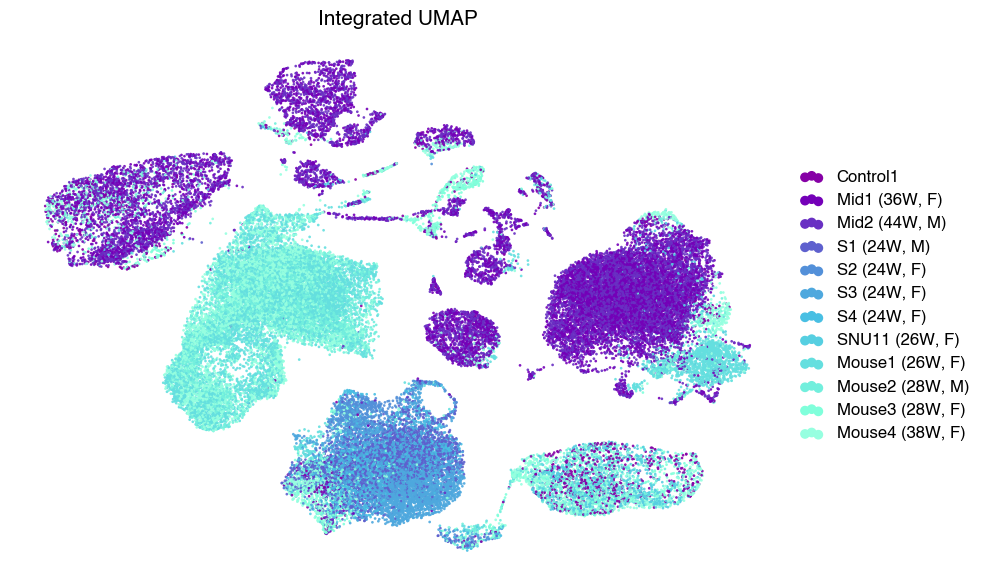

In [18]:
batch_key = 'sample_info'
ri = np.random.permutation(list(range(adata.shape[0])))
with mplscience.style_context():
    plt.rcParams['figure.figsize'] = [10, 7]
    sc.pl.umap(adata[ri,:], color = [batch_key], title = "Integrated UMAP", show=False, frameon=False, size = 15, alpha =0.9, linewidth = 0 )
    # plt.savefig(os.path.join(plot_path, 'Extended_Figure_13a.pdf'), dpi = 300, format = 'pdf', bbox_inches='tight')
    plt.savefig(os.path.join(plot_path, 'reExtended_Figure_13a.pdf'), dpi = 300, format = 'pdf', bbox_inches='tight')
    plt.show()

# Figure 4a

In [25]:
print(adata.obs.cell_type.unique())

['Tumor', 'Neurons', 'Microglia', 'Oligodendrocytes', 'COP', ..., 'T-cells', 'Ependymal cell', 'Endothelial', 'Pericytes', 'Macrophage']
Length: 13
Categories (13, object): ['Astrocytes', 'COP', 'Endothelial', 'Ependymal cell', ..., 'Oligodendrocytes', 'Pericytes', 'T-cells', 'Tumor']


In [26]:
ordered_cell = ['Tumor', 'OPC', 'COP', 'Oligodendrocytes', 'Astrocytes',  'Neural stem cells', 'Neurons',  'Microglia', 'T-cells', 'Macrophage', 'Ependymal cell', 'Endothelial', 'Pericytes',]
adata.obs['cell_type'] = pd.Categorical(values = adata.obs['cell_type'], categories = ordered_cell, ordered = True)

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


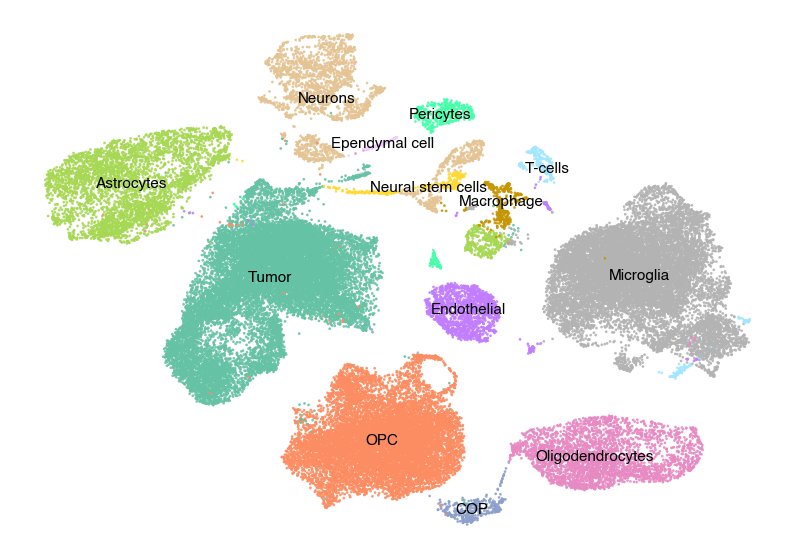

In [19]:
with mplscience.style_context():
    plt.rcParams['figure.figsize'] = [10, 7]
    ax = sc.pl.umap(adata, color = 'cell_type', legend_loc='on data', title = '', frameon=False, show = False, size = 15, alpha = 0.9, linewidth = 0)
    # plt.savefig(os.path.join(plot_path, 'Fig4a.pdf'), dpi = 300, format = 'pdf', bbox_inches='tight')
    plt.savefig(os.path.join(plot_path, 'reFig4a.pdf'), dpi = 300, format = 'pdf', bbox_inches='tight')
    plt.show()

# Extended Figure 19B

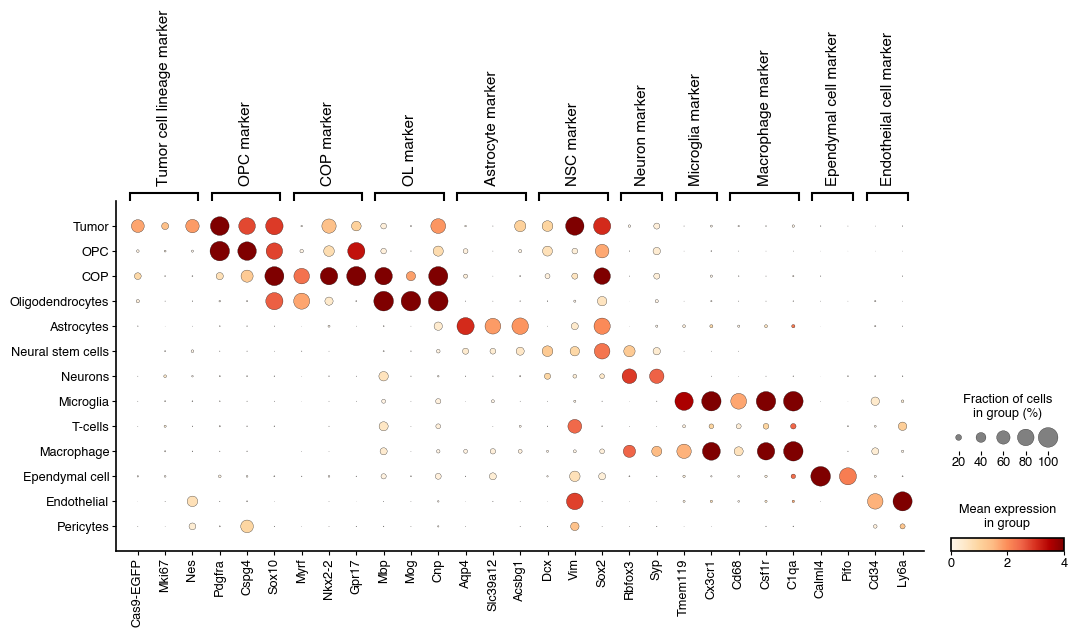

In [18]:
#Finding the marker gene set
marker_genes = {
    "Tumor cell lineage marker" : ["Cas9-EGFP", "Mki67", "Nes"],
    "OPC marker" : ["Pdgfra", "Cspg4", "Sox10"],
    "COP marker" : ["Myrf", "Nkx2-2", "Gpr17"],
    "OL marker" : ["Mbp", "Mog", "Cnp"],
    "Astrocyte marker" : ["Aqp4", "Slc39a12", "Acsbg1"],
    "NSC marker" : ["Dcx", "Vim", "Sox2"],
    "Neuron marker" : ["Rbfox3", "Syp", ],
    "Microglia marker" : ["Tmem119", "Cx3cr1", ], 
    "Macrophage marker" : ["Cd68", "Csf1r", "C1qa"],
    "Ependymal cell marker" : ["Calml4",  "Pifo"], 
    "Endotheilal cell marker" : ["Cd34",  "Ly6a"], 
}
with mplscience.style_context():
    dp_cellmarker = sc.pl.dotplot(adata, marker_genes, groupby="cell_type",  show=False, vmin=0, vmax = 4, cmap='OrRd')
    # dp_cellmarker = sc.pl.dotplot(adata, marker_genes, groupby="cell_type",  show=False,  cmap='OrRd')
    ax = dp_cellmarker["mainplot_ax"]
    for l in ax.get_xticklabels():
        l.set_style("italic")
    fig = ax.get_figure()
    fig.tight_layout()
    # plt.savefig(os.path.join(plot_path, 'Extended_Figure_13b_dotplot.pdf'), dpi = 300, format = 'pdf', bbox_inches='tight')
    plt.show()

In [27]:
cell_type_counts = adata.obs.cell_type.value_counts()
cell_type_counts.to_csv(os.path.join(plot_path, 'cell_type_counts.csv'))

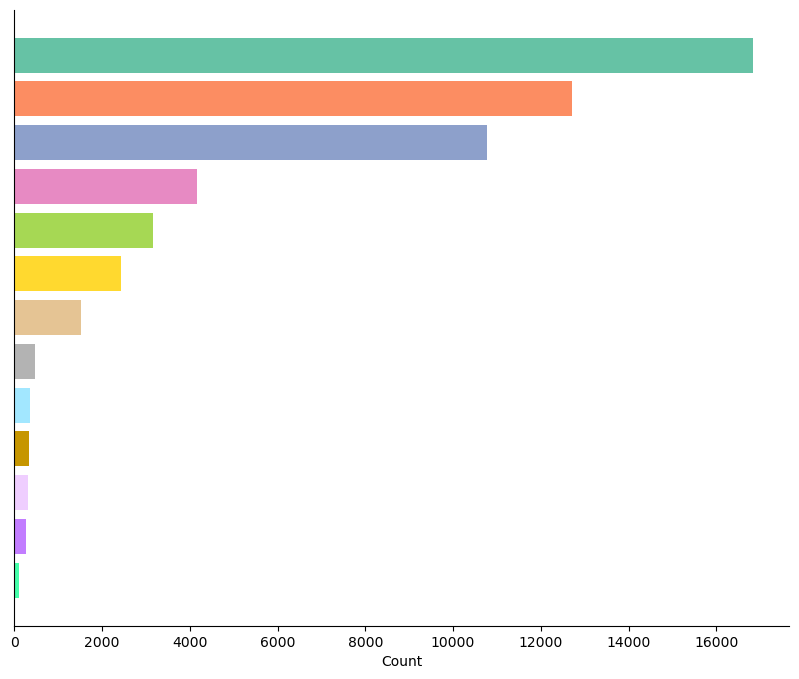

In [ ]:
cell_type_counts = adata.obs.cell_type.value_counts()
cell_types = cell_type_counts.index

plt.figure(figsize=(10, 8))
bars = plt.barh(cell_type_counts.index, cell_type_counts.values, color=cat_color)

plt.grid(False)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_yticks([])

plt.title('')
plt.xlabel('Count')
plt.ylabel('')

plt.gca().invert_yaxis()
plt.savefig(os.path.join(plot_path, 'Extended_Figure_13b_celltype_counts.pdf'), dpi = 300, format = 'pdf', bbox_inches='tight')
plt.show()

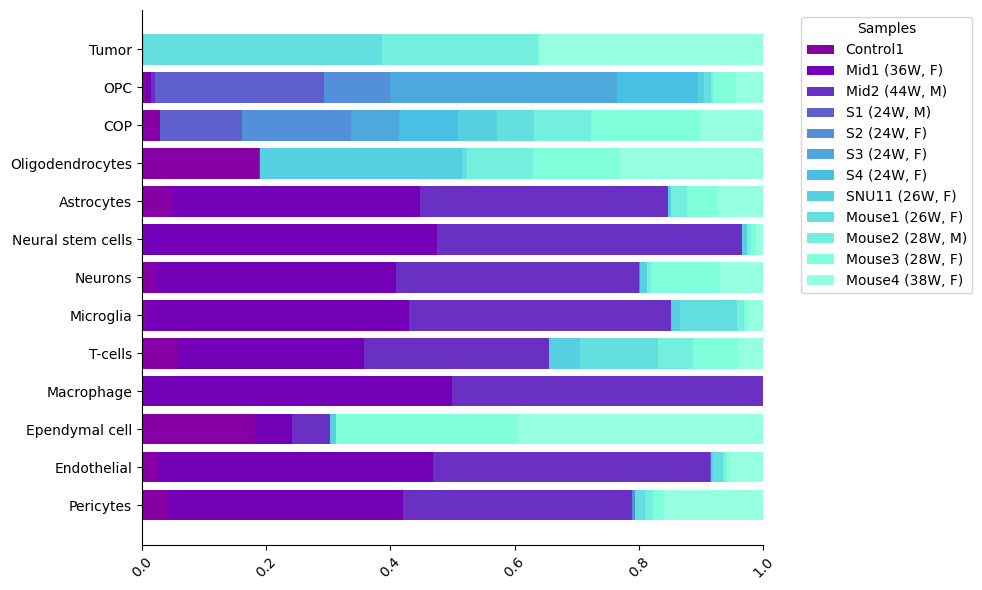

In [31]:
cell_counts = adata.obs.groupby(['cell_type', 'sample_info']).size().unstack(fill_value=0)
proportions = cell_counts.div(cell_counts.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(10, 6))

bottom = None
for i, gfp in enumerate(proportions.columns):
    ax.barh(
        proportions.index,
        proportions[gfp],
        left=bottom,
        # color=sample_color[i % len(sample_color)], 
        color=adata.uns['sample_info_colors'][i], 
        label=gfp,      
    )
    if bottom is None:
        bottom = proportions[gfp]
    else:
        bottom += proportions[gfp]

ax.set_xlabel('')
ax.set_ylabel('')
ax.legend(title='Samples', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.title('')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

plt.gca().invert_yaxis()
plt.tight_layout()

# plt.savefig(os.path.join(plot_path, 'Extended_Figure_13b_mouse_proportions.pdf'), dpi = 300, format = 'pdf', bbox_inches='tight')
plt.savefig(os.path.join(plot_path, 'reExtended_Figure_13b_mouse_proportions.pdf'), dpi = 300, format = 'pdf', bbox_inches='tight')
plt.show()

# Extended Figure 19c

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


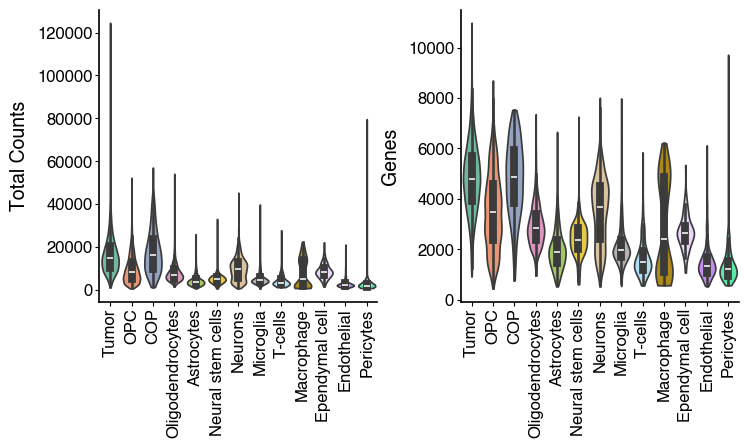

In [18]:
with mplscience.style_context():
    ax = sc.pl.violin(adata, ['total_counts', 'n_genes'], groupby='cell_type', inner="box", stripplot=False, rotation=90, ylabel = ["Total Counts", "Genes"], show=False)
    ax[0].grid(False)
    ax[1].grid(False)
    # plt.savefig(os.path.join(plot_path, 'Extended_Figure_13c.pdf'), dpi = 300, format = 'pdf', bbox_inches='tight')
    plt.savefig(os.path.join(plot_path, 'reExtended_Figure_13c.pdf'), dpi = 300, format = 'pdf', bbox_inches='tight')
    plt.show()

# Extended Figure 20A

In [16]:
cat_color_dict = dict(zip(adata.obs.cell_type.unique(), cat_color))
cat_color_subset = [cat_color_dict[x] for x in ['Tumor', 'OPC', 'COP', 'Oligodendrocytes']]

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


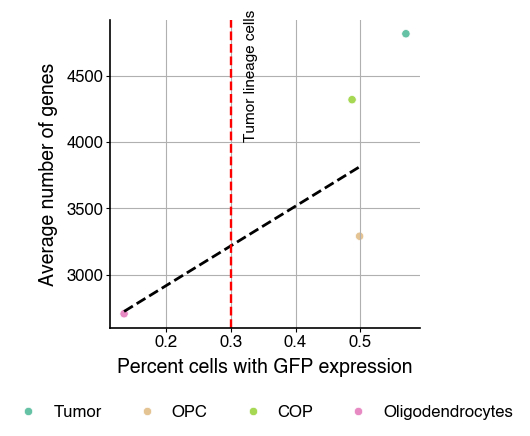

In [17]:
subset = adata[adata.obs.cell_type.isin(['Tumor', 'OPC', 'COP', 'Oligodendrocytes']) & (adata.obs.sample_id.isin(["Control", "Mouse1", "Mouse2", "Mouse3", "Mouse4"]))]
y = subset.obs.groupby('cell_type').n_genes.mean()
x = subset.obs[subset.obs.GFP == 'GFP+'].groupby('cell_type').GFP.count()/subset.obs.groupby('cell_type').GFP.count()

with mplscience.style_context():
    sns.scatterplot(x=x, y=y, hue=y.index, palette=cat_color_subset)
    sns.regplot(x=x[1:], y=y[1:], scatter=False, ci = None, color='black', line_kws={'linestyle':'--', 'linewidth':2})
    plt.axvline(x=0.3, color='red', linestyle='--')
    plt.text(0.32, 4000, 'Tumor lineage cells', rotation=90, verticalalignment='bottom')
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=4)
    plt.xlabel('Percent cells with GFP expression')
    plt.ylabel('Average number of genes')
    plt.grid(None)
    plt.savefig(os.path.join(plot_path, 'Extended_Figure_14c.pdf'), dpi = 300, format = 'pdf', bbox_inches='tight')
    plt.show()

# Aditional 19B

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


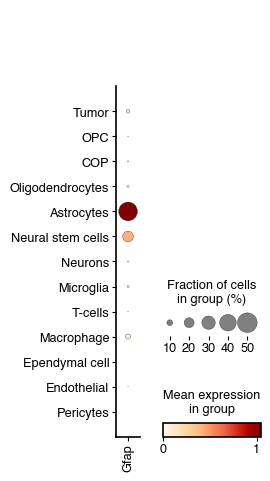

In [19]:
#Finding the marker gene set
with mplscience.style_context():
    dp_cellmarker = sc.pl.dotplot(adata, "Gfap", groupby="cell_type",  show=False, cmap='OrRd')
    ax = dp_cellmarker["mainplot_ax"]
    for l in ax.get_xticklabels():
        l.set_style("italic")
    fig = ax.get_figure()
    fig.tight_layout()
    plt.savefig(os.path.join(plot_path, 'gfap.pdf'), dpi = 300, format = 'pdf', bbox_inches='tight')
    plt.show()